# 2026 OSU Sports Analytics Conference
Goal: Determine how the MLB rule changes in 2023 affected the value of infield defense. This could be from a player evaluation, overall run prevention, or some other perspective.

Data: SIS proprietary defensive measures, player location, and hit location.

* Plays:
    * The data here comes from the 2022 and 2023 seasons.
    * We have included groundballs and line drives under 170 feet from those two seasons.
* Players:
    * Any fielder who SIS deemed as having a greater than zero chance of fielding the ball is included
    * A player will still be included if he was way out of position, but his position's typical alignment might have given him a chance to field the ball.

* Game State Info:
    * We've included a handful of items that could help you evaluate the situational factors involved.
    * If you are interested in the number of outs or the runners on base, we have that info.
    * We also have which at-bat in the inning it was, in case you wish to incorporate other data sources.

* SIS-computed data:
    * Several items from the internal computation of Defensive Runs Saved are included here.
    * Many of them are meant to characterize where players are, where the ball is, and how difficult the play might be to complete.
    * Others are computed expected out rates for the play based on all those factors.
    * These out rates are based on multi-year historical bases that SIS maintains.
    * You can and should use a mix of the calculated out rates and the descriptive fields to assess how teams are positioning players differently, and how it's working out for them.

Submission: Video presentations of less than 5 minutes. Presentations will be evaluated, and finalists will be chosen to present at the Ohio State Sports Analytics conference. Three spots are available for online presentations on March 26.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

blue_color = '#1E90FF' 
red_color = '#EF3E42'
color_palette = {0: blue_color, 1: red_color}

Data dictionary:
* Season - Season the game was played
* GameId - SIS's internal game ID
* Inning - Which inning the play is from
* InningHalf - Which half-inning the play is from (0 is the top half, 1 is the bottom half)
* AtBatIndex - Which at-bat within the inning the play is from
* OutsBefore - How many outs had been recorded earlier in the inning
* RunnerOn1B - Was there a runner on first base?
* RunnerOn2B - Was there a runner on second base?
* RunnerOn3 - Was there a runner on third base?
* BatSide - Batter handedness (Left or Right)
* Pos - Fielder position
* FielderAngle - Angle of the fielder relative to home plate, in degrees. Negative numbers are to the left, positive numbers are to the right from the catcher's perspective.
* FielderDepth - Depth of the fielder relative to home plate, in feet.
* BallInPlayType - Ball in play type (grounder or liner)
* BallInPlayAngle - Angle of the ball in play relative to home plate, in degrees. Negative numbers are to the left, positive numbers are to the right from the catcher's perspective.
* BallInPlayDistance - Distance that the ball traveled. On a groundball, it's where it was fielded. On a line drive, it's where the ball first contacted something.
* BattedBallVelocityGroup - Categorization for how hard the ball was hit, where 1 is soft, 2 is medium, and 3 is hard. This corresponds to the same categories on FanGraphs' stats pages.
* ShiftType - Defensive shift type: Full (three fielders to one side), Partial (not Full, but substantially different from typical), None (no meaningful shift), and Other (a catch-all for situational shifts, e.g. "Infield In")
* BatterSpeedGroup - SIS's internal speed score for the batter, on a scale of 1 (slow) to 5 (fast)
* DistanceToBaseGroup - For the fielding player, roughly how far was he from the most likely base he should throw to when he fielded the ball?
* TimeForThrowGroup - For the fielding player, roughly how much time should he have to complete the play, given the speed of the runner and the timing of the batted ball?
* ExpOutRate_NoPositioning - Expected out rate for this player given historical precedence, knowing only the characteristics of the batted ball
* ExpOutRate_NoPositioning_Team - Expected out rate for the team given historical precedence, knowing only the characteristics of the batted ball
* ExpOutRate_WithPositioning - Expected out rate for this player given historical precedence, knowing the characteristics of the batted ball and the alignment of the fielders
* ExpOutRate_WithPositioning_Team - Expected out rate for the team given historical precedence, knowing the characteristics of the batted ball and the alignment of the fielders
* ExpOutRate_WhenFielded - Expected out rate for this player after the ball is fielded, given how far the throw is and how much time he has to complete the play
* ActualOut	Binary - "was the out recorded by this player", where 1 is a success

In [2]:
data = pd.read_csv('OSU Hackathon 2026 data.csv').copy()

In [3]:
data.isna().sum()

Season                                  0
GameId                                  0
Inning                                  0
InningHalf                              0
AtBatIndex                              0
OutsBefore                              0
RunnerOn1B                              0
RunnerOn2B                              0
RunnerOn3B                              0
BatSide                                 0
Pos                                     0
FielderAngle                            9
FielderDepth                            9
BallInPlayType                          0
BallInPlayAngle                         0
BallInPlayDistance                      0
BattedBallVelocityGroup                 0
ShiftType                           46126
BatterSpeedGroup                        0
DistanceToBaseGroup                105823
TimeForThrowGroup                  105823
ExpOutRate_NoPositioning                0
ExpOutRate_NoPositioning_Team           0
ExpOutRate_WithPositioning        

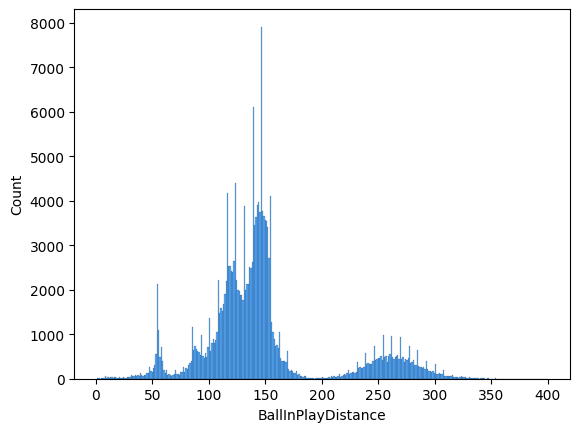

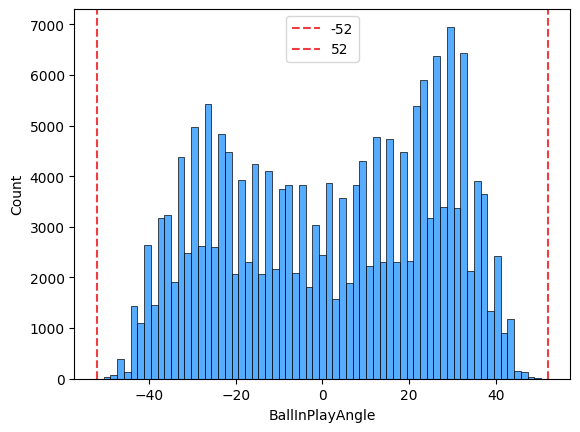

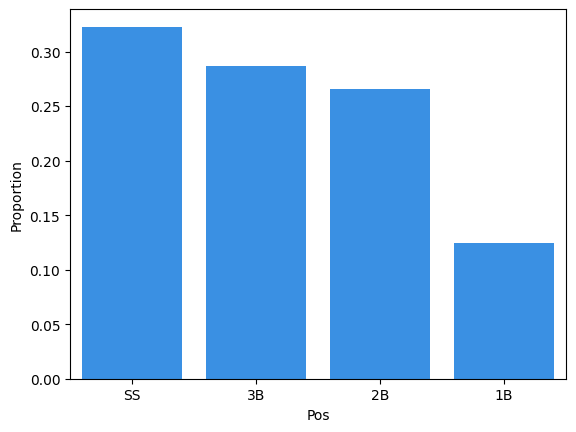

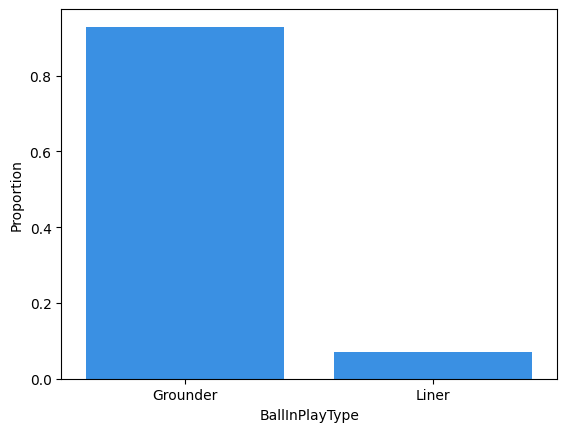

In [4]:
plt.figure()
sns.histplot(data['BallInPlayDistance'], color=blue_color)
plt.show()

plt.figure()
sns.histplot(data=data, x='BallInPlayAngle', color=blue_color)
plt.axvline(x=data['BallInPlayAngle'].min(), label=f'{data['BallInPlayAngle'].min()}', color=red_color, linestyle='dashed')
plt.axvline(x=data['BallInPlayAngle'].max(), label=f'{data['BallInPlayAngle'].max()}', color=red_color, linestyle='dashed')
plt.legend()
plt.show()

plt.figure()
pos_counts = data["Pos"].value_counts(normalize=True).reset_index()
pos_counts.columns = ["Pos", "Proportion"]
sns.barplot(data=pos_counts, x="Pos", y="Proportion", color=blue_color)
plt.show()

plt.figure()
bip_counts = data["BallInPlayType"].value_counts(normalize=True).reset_index()
bip_counts.columns = ["BallInPlayType", "Proportion"]
sns.barplot(data=bip_counts, x="BallInPlayType", y="Proportion", color=blue_color)
plt.show()

In [5]:
# data cleaning + preprocessing

## can just get rid of these 9 plays (out of 100K)
data = data[~data['FielderAngle'].isna()].reset_index(drop=True).copy()

## null values occurred when there just wasn't a shift
data['ShiftType'] = data['ShiftType'].fillna('None')

## reorienting BallInPlayAngle + FielderAngle, and converting them to radians
data['BallInPlayAngle'] = data['BallInPlayAngle'].apply(lambda x: ((90-x)*np.pi) / 180)
data['FielderAngle'] = data['FielderAngle'].apply(lambda x: ((90-x)*np.pi) / 180)

## polar coords to carteisan plane for the batted ball (figuring out the X, Y coords for where the ball was fielded by the infielder)
data['X_ball_coord'] = data['BallInPlayDistance'] * np.cos(data['BallInPlayAngle'])
data['Y_ball_coord'] = data['BallInPlayDistance'] * np.sin(data['BallInPlayAngle'])

## polar coords to carteisan plane for the fielder's pos (figuring out the X, Y coords for where the infielder is at)
data['X_fielder_coord'] = data['FielderDepth'] * np.cos(data['FielderAngle'])
data['Y_fielder_coord'] = data['FielderDepth'] * np.sin(data['FielderAngle'])

In [6]:
## the foul lines to be visualized
lf_x_values = np.linspace(0, -300)
lf_foul_line = -lf_x_values
rf_x_values = np.linspace(0, 300)
rf_foul_line = rf_x_values

## the coords of each base
bases_x = [90, 0, 0, -90]
bases_y = [90, 0, np.sqrt(90**2 + 90**2), 90]

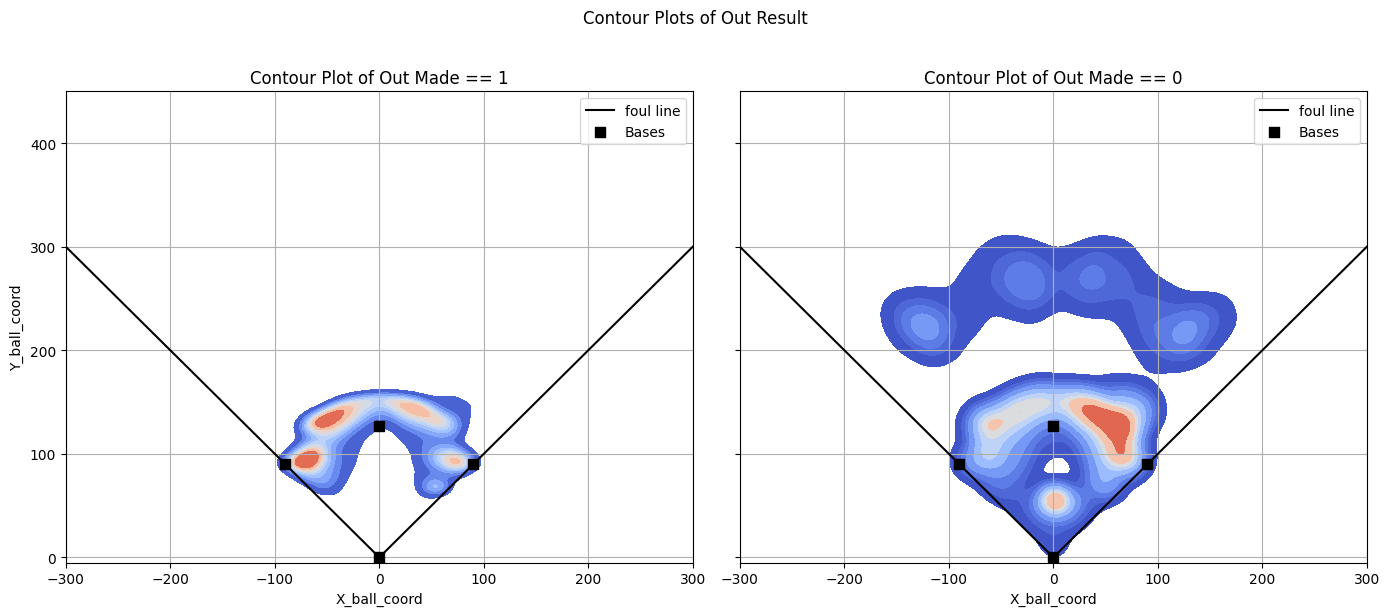

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, out_val in zip(axes, [1, 0]):
    subset = data[data["ActualOut"] == out_val]
    sns.kdeplot(data=subset, x="X_ball_coord", y="Y_ball_coord", fill=True, cmap="coolwarm", ax=ax,)
    ax.plot(lf_x_values, lf_foul_line, c="black", label="foul line")
    ax.plot(rf_x_values, rf_foul_line, c="black")
    ax.scatter(bases_x, bases_y, color="black", marker="s", s=50, label="Bases", zorder=5)
    ax.set_xlim(-300, 300)
    ax.set_ylim(-5, 450)
    ax.set_title(f"Contour Plot of Out Made == {out_val}")
    ax.grid()
    ax.legend()
fig.suptitle("Contour Plots of Out Result", y=1.02)
fig.tight_layout()
plt.show()

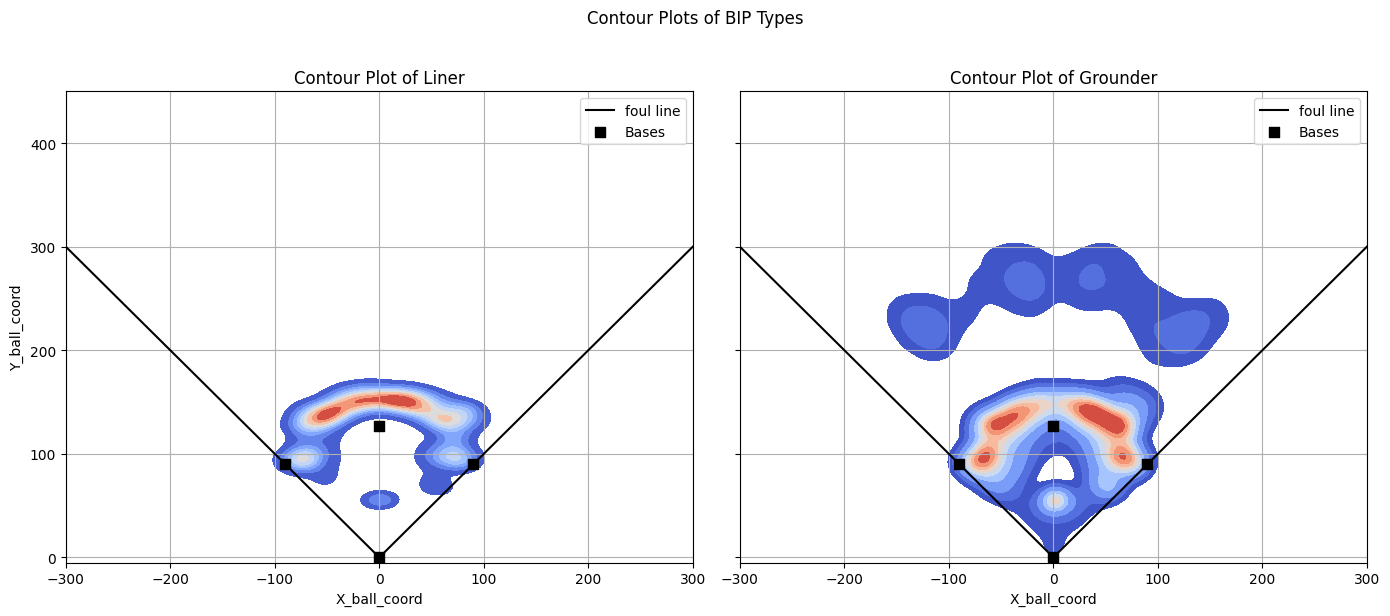

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, bip_type in zip(axes, ['Liner', 'Grounder']):
    subset = data[data["BallInPlayType"] == bip_type]
    sns.kdeplot(data=subset, x="X_ball_coord", y="Y_ball_coord", fill=True, cmap="coolwarm", ax=ax,)
    ax.plot(lf_x_values, lf_foul_line, c="black", label="foul line")
    ax.plot(rf_x_values, rf_foul_line, c="black")
    ax.scatter(bases_x, bases_y, color="black", marker="s", s=50, label="Bases", zorder=5)
    ax.set_xlim(-300, 300)
    ax.set_ylim(-5, 450)
    ax.set_title(f"Contour Plot of {bip_type}")
    ax.grid()
    ax.legend()
fig.suptitle("Contour Plots of BIP Types", y=1.02)
fig.tight_layout()
plt.show()

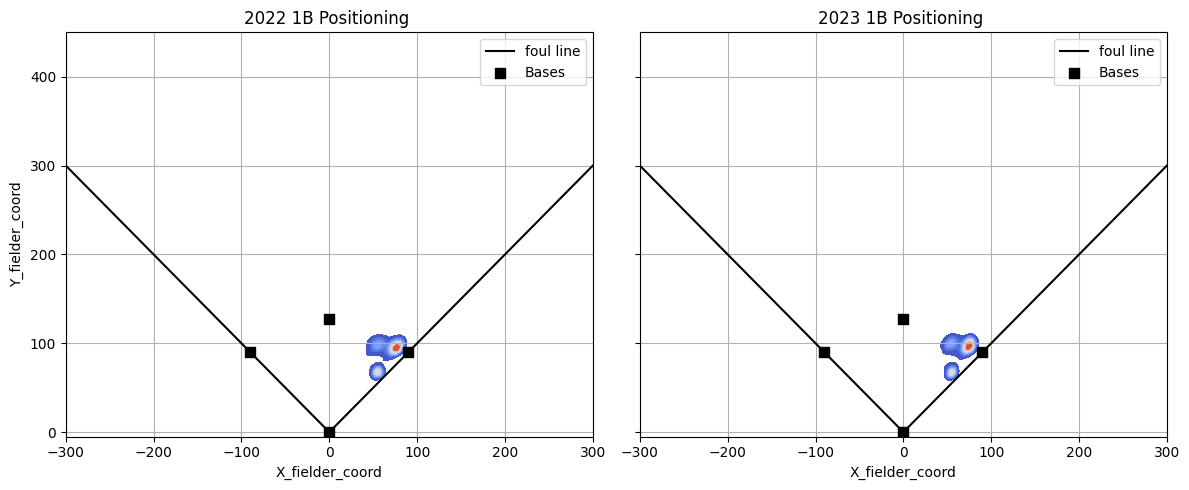

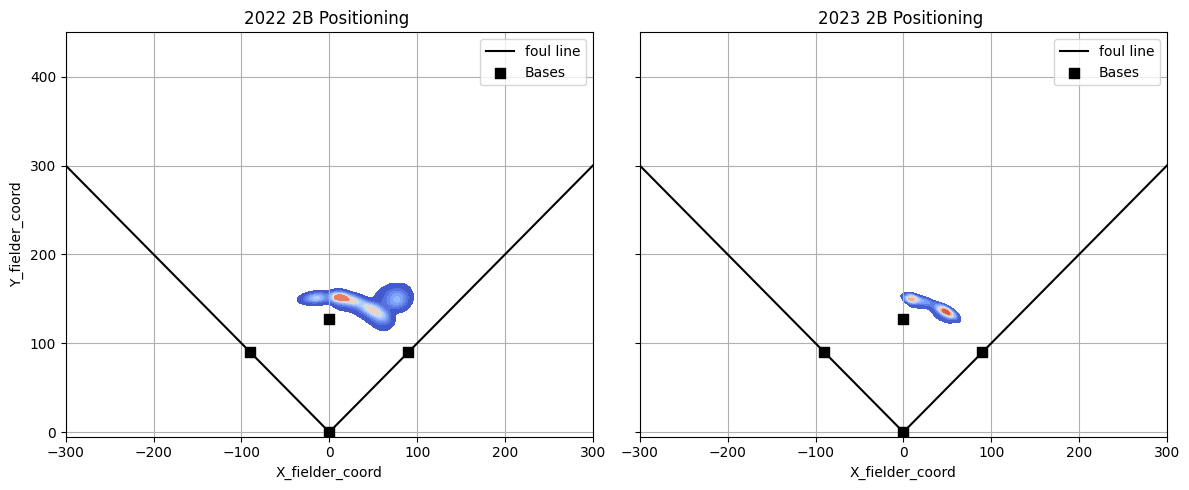

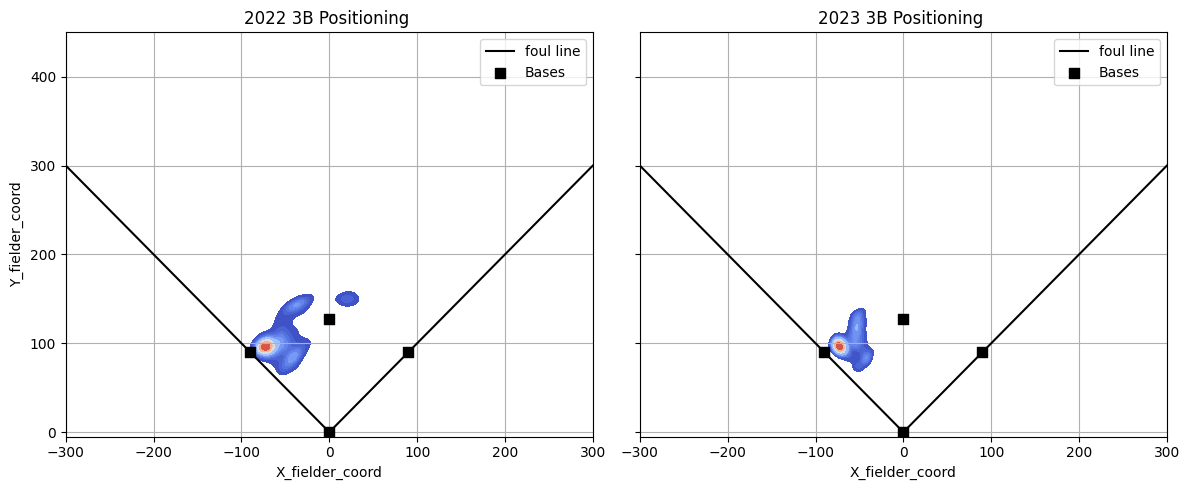

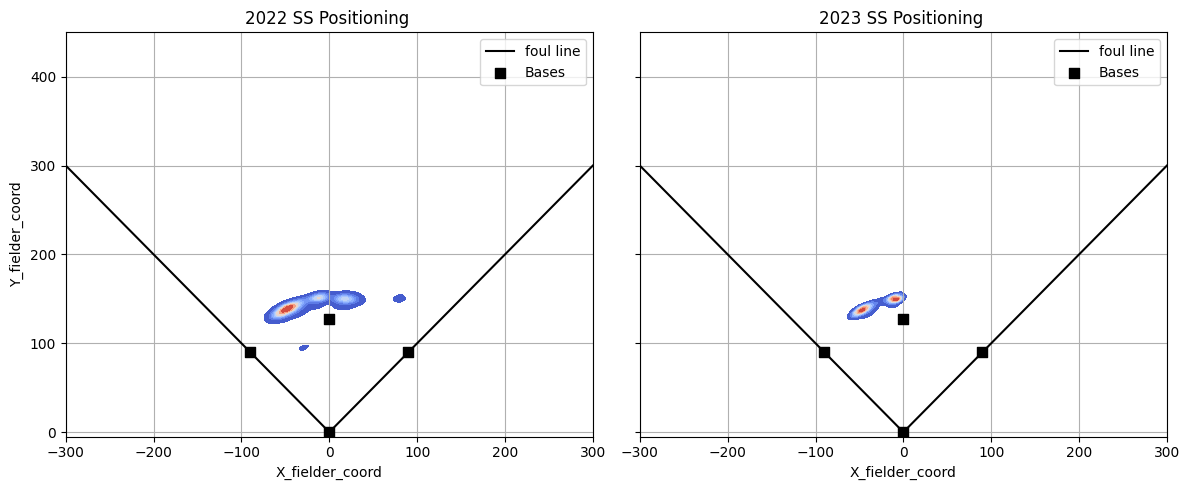

In [9]:
for pos in ['1B', '2B', '3B', 'SS']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    for ax, szn in zip(axes, [2022, 2023]):
        specific_pos = data[(data["Pos"] == pos) & (data["Season"] == szn)]
        sns.kdeplot(data=specific_pos, x="X_fielder_coord", y="Y_fielder_coord", fill=True, cmap='coolwarm', ax=ax)
        ax.set_title(f"{szn} {pos} Positioning ")
        ax.plot(lf_x_values, lf_foul_line, c="black", label="foul line")
        ax.plot(rf_x_values, rf_foul_line, c="black")
        ax.scatter(bases_x, bases_y, color='black', marker='s', s=50, label='Bases', zorder=5)
        ax.set_xlim(-300, 300)
        ax.set_ylim(-5, 450)
        ax.grid()
        ax.legend()
    fig.tight_layout()
    plt.show()